<a href="https://colab.research.google.com/github/kt0670/image-caption-generator/blob/main/notebooks/blip_captioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install transformers datasets Pillow gradio
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests

# Load pretrained BLIP model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Test with a sample image from the web
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
#image = Image.open("fairies.jpeg")

# Generate caption
inputs = processor(image, return_tensors="pt")
output = model.generate(**inputs)
caption = processor.decode(output[0], skip_special_tokens=True)
print(caption)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


two cats sleeping on a couch


In [9]:
!pip install kaggle
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_045ee46c7f087e5b071f01de001ca401"
!kaggle datasets download -d adityajn105/flickr8k
!unzip flickr8k.zip -d /content/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
flickr8k.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  flickr8k.zip
replace /content/flickr8k/Images/1000268201_693b08cb0e.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

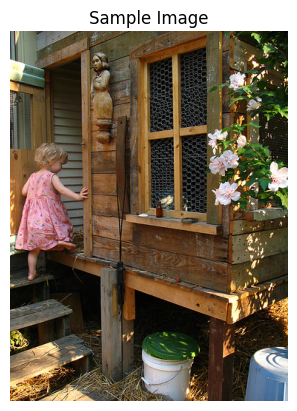

Captions:
1. A child in a pink dress is climbing up a set of stairs in an entry way .
2. A girl going into a wooden building .
3. A little girl climbing into a wooden playhouse .
4. A little girl climbing the stairs to her playhouse .
5. A little girl in a pink dress going into a wooden cabin .


In [6]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Pick a sample image
sample_image = df['image'][0]
sample_captions = df[df['image'] == sample_image]['caption'].tolist()

# Display it
img = Image.open(f"/content/flickr8k/Images/{sample_image}")
plt.imshow(img)
plt.axis('off')
plt.title("Sample Image")
plt.show()

# Print its captions
print("Captions:")
for i, cap in enumerate(sample_captions):
    print(f"{i+1}. {cap}")

In [17]:
from torch.utils.data import Dataset

class FlickrDataset(Dataset):
  def __init__(self, df, img, processor):
    super(FlickrDataset, self).__init__()
    self.df = df
    self.img = img
    self.processor = processor

  def __len__(self):
    return len(self.df)

  def __getitem__(self, index):
    row = self.df.iloc[index]
    image = row['image']
    img = Image.open(f"/content/flickr8k/Images/{image}").convert("RGB")
    inputs = self.processor(images=img, text=row['caption'], padding="max_length",
                       max_length=128, return_tensors="pt")
    return(inputs)

test_dataset = FlickrDataset(df, "/content/flickr8k/Images", processor)
sample = test_dataset[0]
print(sample.keys())
#print(len(test_dataset))

KeysView({'input_ids': tensor([[ 101, 1037, 2775, 1999, 1037, 5061, 4377, 2003, 8218, 2039, 1037, 2275,
         1997, 5108, 1999, 2019, 4443, 2126, 1012,  102,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        